# Building a Convolutional Neural Network to classify digits from MNIST dataset

## 0. Importing depenencies, checking GPU availability and setting up device agnostic code

In [135]:
import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision.transforms import ToTensor

from torchmetrics.classification import Accuracy

import matplotlib.pyplot as plt

from pathlib import Path

In [136]:
!nvidia-smi

Tue Aug 25 21:38:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             30W /   70W |     193MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [137]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [138]:
device

'cuda'

## 1. Preparing data

In [139]:
train_data = datasets.MNIST(root="data", download=True, train=True, transform=ToTensor(), target_transform=None)
test_data = datasets.MNIST(root="data", download=True, train=False, transform=ToTensor(), target_transform=None)

train_dataloader = DataLoader(dataset=train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=32, shuffle=False)

In [140]:
first_image, first_label = train_data[0]
first_image.shape

torch.Size([1, 28, 28])

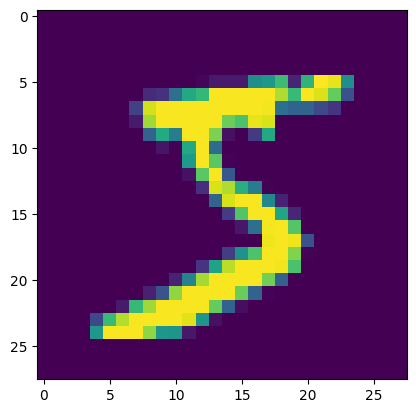

In [141]:
plt.imshow(first_image.squeeze());

In [142]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 2. Building a model

In [143]:
class MnistModelCNN(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
        )

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        X = self.conv_block_1(X)
        X = self.conv_block_2(X)
        X = self.classifier(X)
        return X



In [144]:
model = MnistModelCNN(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)


## 3. Setting up loss function, optimizer and accuracy

In [145]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)
accuracy = Accuracy(task="multiclass", num_classes=10).to(device)

## 4. Setting up manual seed

In [146]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

## 5. Coding the training and testing loop

In [147]:
epochs = 15
train_loss, train_acc = 0, 0

for epoch in range(epochs):
    train_loss, train_acc = 0, 0
    model.train()
    for X_batch, y_batch in train_dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        train_loss += loss.item()
        train_acc += accuracy(y_pred.argmax(dim=1), y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    if epoch % 5 == 0:
        test_loss, test_acc = 0, 0
        model.eval()
        with torch.inference_mode():
            for X_batch, y_batch in test_dataloader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                test_preds = model(X_batch)
                test_loss += loss_fn(test_preds, y_batch).item()
                test_acc += accuracy(test_preds.argmax(dim=1), y_batch)

            test_loss /= len(test_dataloader)
            test_acc /= len(test_dataloader)

        print(f"Epoch: {epoch}, Train loss: {train_loss}, Test loss: {test_loss}, Train accuracy: {train_acc}, Test accuracy: {test_acc}")


Epoch: 0, Train loss: 1.7714390220781167, Test loss: 0.34485510278481263, Train accuracy: 0.3550499975681305, Test accuracy: 0.8933705687522888
Epoch: 5, Train loss: 0.06702102546089639, Test loss: 0.052528337847471934, Train accuracy: 0.9790666699409485, Test accuracy: 0.9838258624076843
Epoch: 10, Train loss: 0.047792383890242006, Test loss: 0.05206240260915551, Train accuracy: 0.9854666590690613, Test accuracy: 0.9833266735076904


## 6. Saving model to a file

In [148]:
model_folder = Path("models")
model_folder.mkdir(parents=True, exist_ok=True)
model_name = "mnist_model.pth"

torch.save(obj=model.state_dict(), f=model_folder/model_name)